# PIB total vs PIB per cápita en la Unión Europea, y el papel de la inmigración

Es habitual escuchar que "la inmigración hace crecer la economía". En un sentido estricto es cierto casi por definición: más personas trabajando producen más **PIB total**. Pero un aumento del PIB total no implica automáticamente una mejora del nivel de vida medio, que se aproxima mejor con el **PIB per cápita**.

Este proyecto compara ambos indicadores para varios países de la Unión Europea y explora, con datos ilustrativos de población y saldo migratorio, un caso concreto donde esa diferencia es especialmente relevante.

**Fuentes de datos (Eurostat):**
- `tec00114` — PIB per cápita en PPS (índice, UE27 = 100)
- `tec00115` — Tasa de crecimiento real del PIB
- `tps00001` — Población a 1 de enero
- `tps00019` — Cambio de población, incluido el saldo migratorio neto

Si no se ha ejecutado `fetch_data.py`, se usan datos de ejemplo **ilustrativos** (`data/sample_pib.csv`). Las columnas de población y saldo migratorio de ese archivo son estimaciones aproximadas construidas para ilustrar el análisis, no una descarga directa de Eurostat, así que no deben citarse como cifras oficiales.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

REAL_PATH = Path("data/pib_real.csv")
SAMPLE_PATH = Path("data/sample_pib.csv")

if REAL_PATH.exists():
    print("Usando datos reales descargados de Eurostat (data/pib_real.csv)")
    df = pd.read_csv(REAL_PATH)
else:
    print("No se encontró data/pib_real.csv -> usando data/sample_pib.csv (datos ILUSTRATIVOS, no oficiales)")
    df = pd.read_csv(SAMPLE_PATH)

df.head()

No se encontró data/pib_real.csv -> usando data/sample_pib.csv (datos ILUSTRATIVOS, no oficiales)


,pais,anio,pib_per_capita_pps_indice,pib_crecimiento_real_pct,poblacion_millones,saldo_migratorio_neto_por_mil
0,España,2015,91,3.8,46.4,1.0
1,España,2016,92,3.0,46.5,2.5
2,España,2017,92,3.0,46.6,4.0
3,España,2018,91,2.3,46.9,6.0
4,España,2019,91,2.1,47.1,6.5


## 1. Evolución del PIB per cápita (PPS) por país

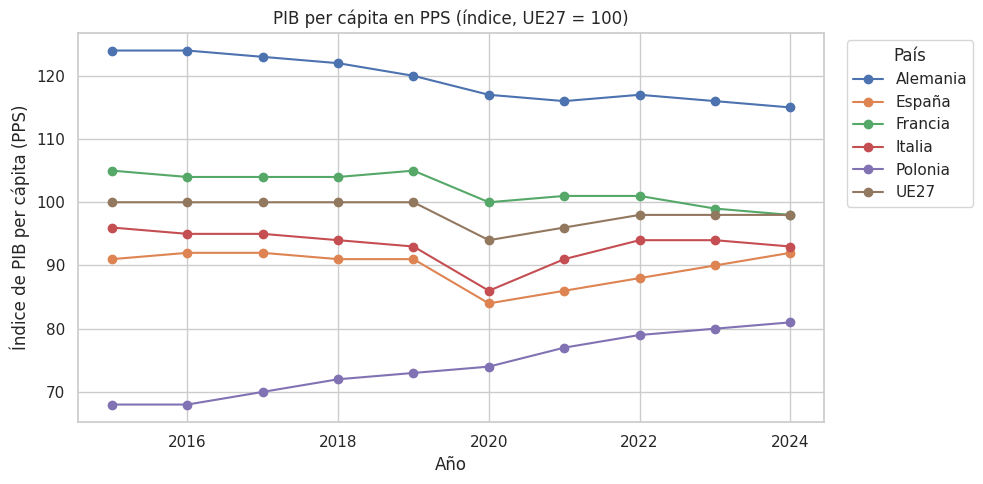

In [2]:
fig, ax = plt.subplots()
for pais, grupo in df.groupby("pais"):
    ax.plot(grupo["anio"], grupo["pib_per_capita_pps_indice"], marker="o", label=pais)

ax.set_title("PIB per cápita en PPS (índice, UE27 = 100)")
ax.set_xlabel("Año")
ax.set_ylabel("Índice de PIB per cápita (PPS)")
ax.legend(title="País", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("pib_per_capita_evolucion.png", dpi=150)
plt.show()

## 2. PIB total vs PIB per cápita: ¿crecen igual?

Comparamos el crecimiento acumulado del PIB real (tamaño total de la economía) frente al cambio en el índice de PIB per cápita, para el periodo disponible.

In [3]:
resumen = (
    df.groupby("pais")
    .apply(lambda g: pd.Series({
        "crecimiento_pib_acumulado_%": g.sort_values("anio")["pib_crecimiento_real_pct"].sum(),
        "cambio_pib_per_capita_indice": g.sort_values("anio")["pib_per_capita_pps_indice"].iloc[-1]
                                       - g.sort_values("anio")["pib_per_capita_pps_indice"].iloc[0],
    }))
    .reset_index()
    .sort_values("crecimiento_pib_acumulado_%", ascending=False)
)
resumen

,pais,crecimiento_pib_acumulado_%,cambio_pib_per_capita_indice
4,Polonia,35.8,13.0
1,España,21.7,1.0
5,UE27,16.4,-2.0
2,Francia,12.5,-7.0
3,Italia,10.1,-3.0
0,Alemania,9.4,-9.0


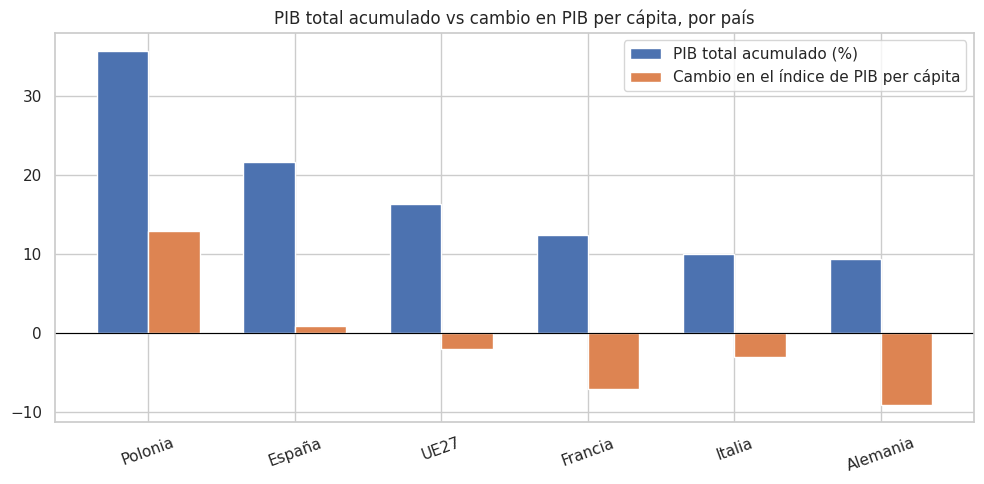

In [4]:
fig, ax = plt.subplots()
x = range(len(resumen))
width = 0.35

ax.bar([i - width / 2 for i in x], resumen["crecimiento_pib_acumulado_%"], width, label="PIB total acumulado (%)")
ax.bar([i + width / 2 for i in x], resumen["cambio_pib_per_capita_indice"], width, label="Cambio en el índice de PIB per cápita")

ax.set_xticks(list(x))
ax.set_xticklabels(resumen["pais"], rotation=20)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("PIB total acumulado vs cambio en PIB per cápita, por país")
ax.legend()
plt.tight_layout()
plt.savefig("pib_total_vs_per_capita.png", dpi=150)
plt.show()

**Lectura del gráfico:** cuando las dos barras están muy separadas para un país, el PIB total y el PIB per cápita se han movido de forma distinta. Eso puede pasar, entre otros motivos, cuando la población crece a un ritmo parecido al de la economía: el PIB total sube, pero lo que le corresponde a cada persona apenas cambia.

## 3. ¿Explica el crecimiento de la población parte de esa diferencia?

Comparamos el crecimiento de la población con el crecimiento del PIB total y el cambio en el PIB per cápita. La inmigración es, en la mayoría de estos países, el principal componente del crecimiento de la población (el saldo entre nacimientos y muertes es plano o negativo en varios de ellos).

In [5]:
crecimiento_poblacion = (
    df.groupby("pais")
    .apply(lambda g: pd.Series({
        "crecimiento_poblacion_%": (
            (g.sort_values("anio")["poblacion_millones"].iloc[-1]
             / g.sort_values("anio")["poblacion_millones"].iloc[0]) - 1
        ) * 100,
        "saldo_migratorio_medio_por_mil": g["saldo_migratorio_neto_por_mil"].mean(),
    }))
    .reset_index()
)

comparativa = resumen.merge(crecimiento_poblacion, on="pais").sort_values("crecimiento_pib_acumulado_%", ascending=False)
comparativa

,pais,crecimiento_pib_acumulado_%,cambio_pib_per_capita_indice,crecimiento_poblacion_%,saldo_migratorio_medio_por_mil
0,Polonia,35.8,13.0,-3.947368,2.09
1,España,21.7,1.0,4.741379,5.30
2,UE27,16.4,-2.0,0.649060,2.47
3,Francia,12.5,-7.0,3.157895,0.82
4,Italia,10.1,-3.0,-3.125000,2.56
5,Alemania,9.4,-9.0,2.955665,5.95


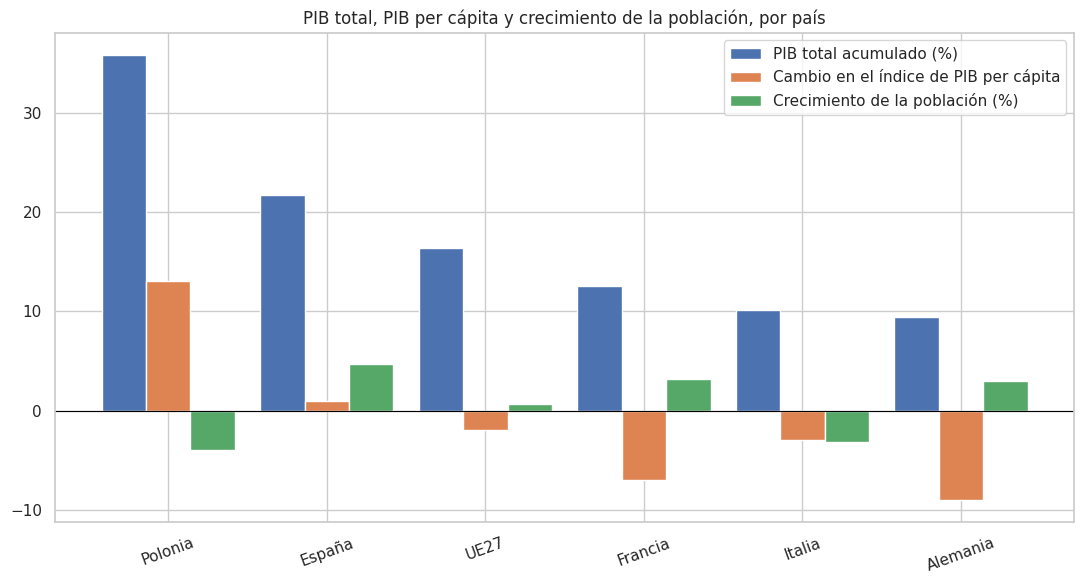

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(comparativa))
width = 0.28

ax.bar([i - width for i in x], comparativa["crecimiento_pib_acumulado_%"], width, label="PIB total acumulado (%)")
ax.bar(x, comparativa["cambio_pib_per_capita_indice"], width, label="Cambio en el índice de PIB per cápita")
ax.bar([i + width for i in x], comparativa["crecimiento_poblacion_%"], width, label="Crecimiento de la población (%)")

ax.set_xticks(list(x))
ax.set_xticklabels(comparativa["pais"], rotation=20)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("PIB total, PIB per cápita y crecimiento de la población, por país")
ax.legend()
plt.tight_layout()
plt.savefig("pib_poblacion_comparativa.png", dpi=150)
plt.show()

**Dos casos ilustrativos que conviene mirar con atención:**

- **España**, en los datos de este ejemplo, combina un saldo migratorio positivo y creciente con un PIB per cápita que se recupera después de 2020, pero que en el conjunto del periodo avanza más despacio que el PIB total.
- **Italia**, en cambio, recibe inmigración de forma sostenida y, aun así, su población total desciende: el saldo migratorio positivo no compensa un saldo natural (nacimientos menos defunciones) muy negativo. Es un buen recordatorio de que la población no depende solo de la inmigración.

Esto no demuestra causalidad — para eso haría falta la metodología descrita en la sección de econometría del artículo que acompaña a este proyecto (diferencias en diferencias, variables instrumentales, control de otros factores). Lo que sí muestra es que **PIB total, PIB per cápita y población son tres variables distintas que no siempre se mueven juntas**, y que reducir el debate a "sube o no sube el PIB" deja fuera la parte más relevante para el nivel de vida medio.

## 4. Saldo migratorio neto vs cambio en el PIB per cápita

Este gráfico de dispersión sitúa cada país según su saldo migratorio medio (eje X) y el cambio en su PIB per cápita durante el periodo (eje Y). **Es una relación puramente descriptiva**, sin controlar por productividad, sector económico, políticas públicas ni ningún otro factor — no debe interpretarse como una prueba de causalidad en ningún sentido.

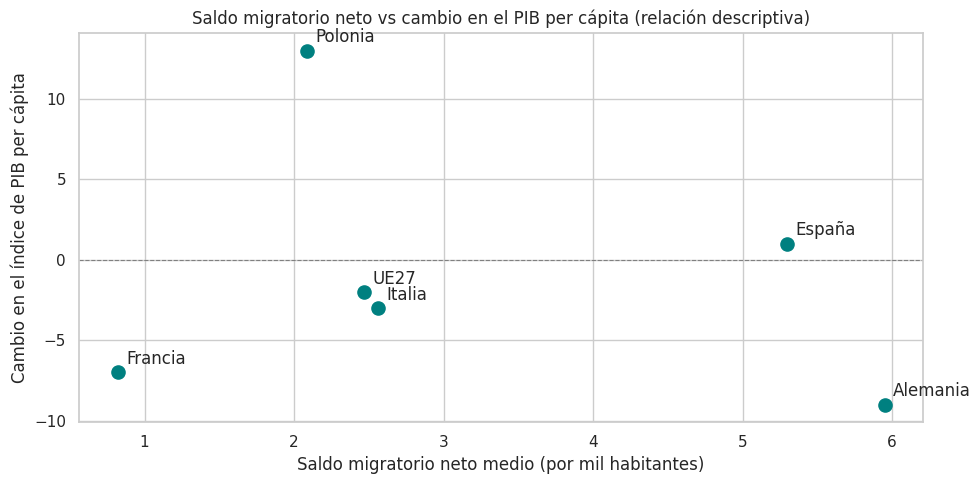

In [7]:
fig, ax = plt.subplots()
ax.scatter(comparativa["saldo_migratorio_medio_por_mil"], comparativa["cambio_pib_per_capita_indice"], s=90, color="teal")

for _, fila in comparativa.iterrows():
    ax.annotate(fila["pais"], (fila["saldo_migratorio_medio_por_mil"], fila["cambio_pib_per_capita_indice"]),
                textcoords="offset points", xytext=(6, 6))

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Saldo migratorio neto medio (por mil habitantes)")
ax.set_ylabel("Cambio en el índice de PIB per cápita")
ax.set_title("Saldo migratorio neto vs cambio en el PIB per cápita (relación descriptiva)")
plt.tight_layout()
plt.savefig("migracion_vs_pib_per_capita.png", dpi=150)
plt.show()

## 5. Ranking de PIB per cápita en el último año disponible

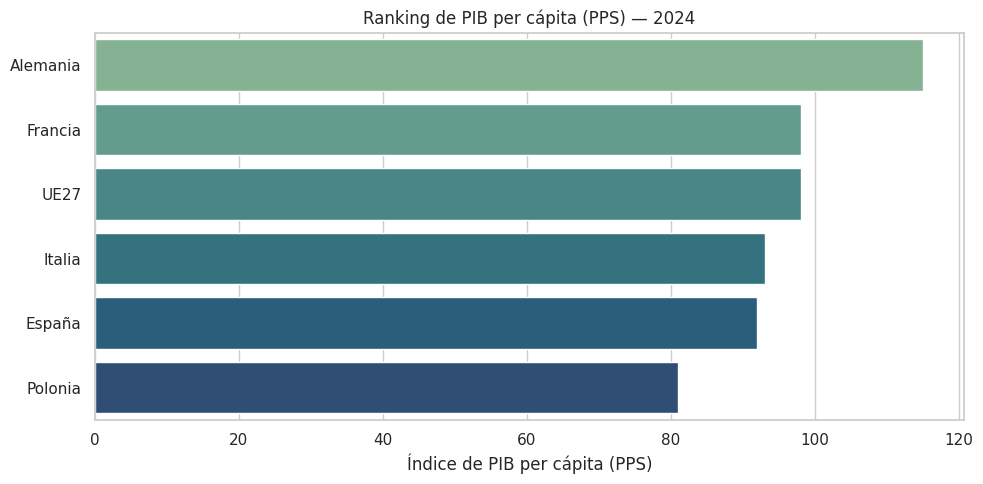

In [8]:
ultimo_anio = df["anio"].max()
ranking = df[df["anio"] == ultimo_anio].sort_values("pib_per_capita_pps_indice", ascending=False)

fig, ax = plt.subplots()
sns.barplot(data=ranking, x="pib_per_capita_pps_indice", y="pais", hue="pais", legend=False, palette="crest", ax=ax)
ax.set_title(f"Ranking de PIB per cápita (PPS) — {ultimo_anio}")
ax.set_xlabel("Índice de PIB per cápita (PPS)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("ranking_pib_per_capita.png", dpi=150)
plt.show()

## Conclusiones

- El PIB total y el PIB per cápita **no siempre se mueven en la misma dirección ni a la misma velocidad**. Un país puede mostrar buen crecimiento agregado y, aun así, quedarse atrás en PIB per cápita si su población crece a un ritmo parecido.
- La inmigración puede aumentar el PIB total casi por definición (más personas trabajando producen más), pero eso **no implica automáticamente una mejora del PIB per cápita ni del nivel de vida medio** — depende de cómo se compare el crecimiento de la producción con el crecimiento de la población.
- Al mismo tiempo, hay evidencia (mencionada en el artículo que acompaña a este proyecto) de que, a medio y largo plazo, la inmigración también puede mejorar el PIB per cápita en países con población envejecida, al ampliar la base de cotizantes. La relación no es unidireccional ni está cerrada: depende del tipo de inmigración, del sector receptor y del horizonte temporal considerado.
- El caso de Italia recuerda que la población no depende solo del saldo migratorio: el saldo natural (nacimientos menos defunciones) también pesa, y en varios países europeos pesa en sentido contrario.

**Limitaciones de este análisis:** los datos de población y saldo migratorio usados aquí son ilustrativos, el número de países es reducido, y el gráfico de dispersión de la sección 4 es puramente descriptivo. Para conclusiones causales robustas haría falta aplicar las técnicas econométricas descritas en la sección 5 del artículo (diferencias en diferencias, variables instrumentales tipo shift-share, control de otros factores).